<h1 style="text-align: center;">Visualización geoespacial de precios</h1>

El intento de esta extension va a ser visualizar la distribucion de los precios desde un punto de vista geoespacial, y ver si emergen patrones dentro de esta distribucion. Ademas, en caso de que existan dichos patrones, queremos comprobar si estos estan relaciondos con alguna otra variable que no sea el precio en si mismo, en especial, nos vamos a fijar en las 'ammenities' que definimos para nuestro modelo.

Antes de comenzar el analisis, queremos formular la siguiente hipotesis de que nosotros creemos que los precios de alquiler en el AMBA estan relacionados con la cantidad de 'ammenities' que posee la propiedad. Es decir, creemos que a mayor cantidad de 'ammenities' mayor va a ser el precio de alquiler.

In [10]:
import numpy as np
import pandas as pd
import geopandas as gpd
import src.utils as ut
import matplotlib.pyplot as plt

In [11]:
data = pd.read_csv(r'data/processed/data_preprocessed.csv')
print(data.shape)

(274268, 22)


Lo primero que queremos hacer es visualizar como se distriuyen los precios de alquiler sobre el AMBA. Entonces, como primer paso, vamos a cargar los datos y ver como se ven en un mapa. Para eso, vamos a utilizar la librería `geopandas` que nos permite trabajar con datos geoespaciales:

Cantidad de datos: 98.4 %


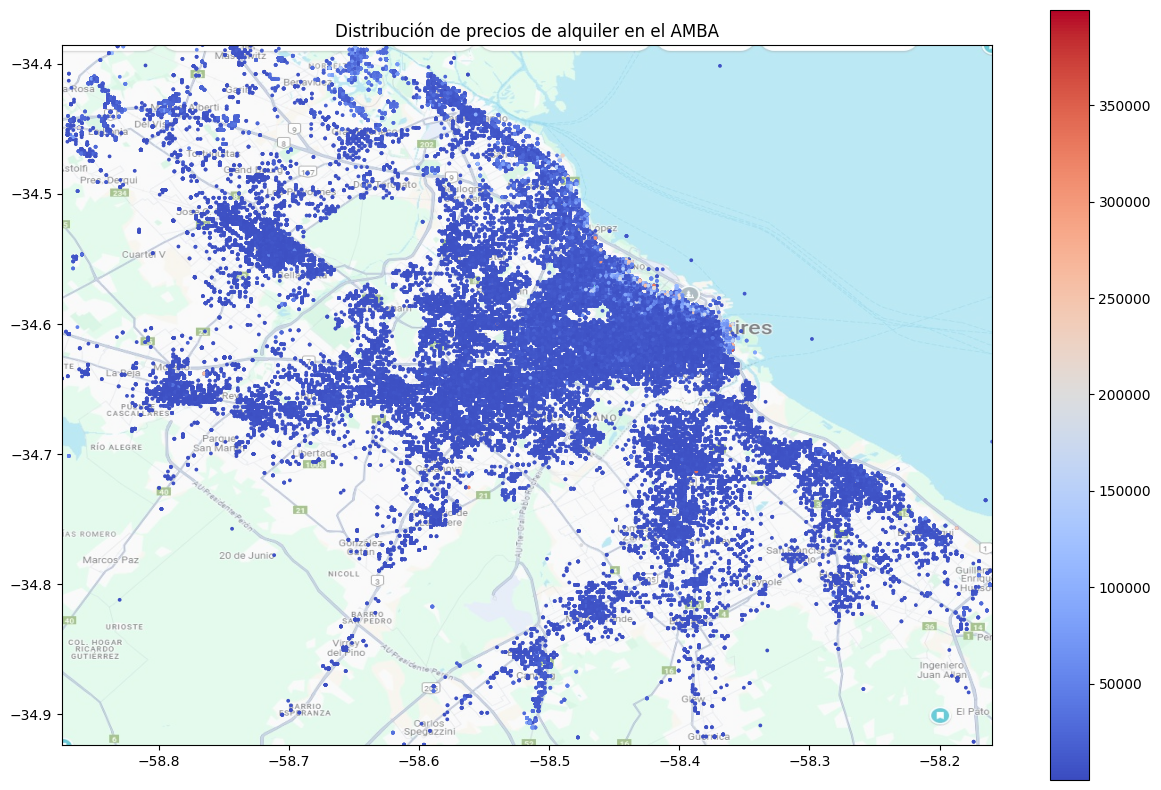

In [12]:
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.LONGITUDE, data.LATITUDE))
print(f'Cantidad de datos: {np.round(len(data) / 278725, 4) * 100} %')

fig, ax = plt.subplots(figsize=(15, 10))
gdf.plot(column='precio_pesos_constantes', cmap='coolwarm', legend=True, markersize=3, ax=ax)
img = plt.imread(r'img/map.jpg')
ax.imshow(img, extent=[data['LONGITUDE'].min(), data['LONGITUDE'].max(), data['LATITUDE'].min(), data['LATITUDE'].max()], alpha=0.6)
plt.title("Distribución de precios de alquiler en el AMBA")
plt.show()

A primera vista, lo primero que podemos notar es una diferencia entre los precios de la capital (y algunas zonas del norte del AMBA) con el resto de la region, lo cual era de esperarse ya que la capital es la parte centrica de la provincia, mientras que el AMBA es periferia.

Sin embargo, no podemos notar mucho una distribucion muy clara, igualmente esto se debe a los altos valores que acumulan algunos lugares del AMBA en comparacion con otros. Para poder visualizar mejor la distribucion de los precios, tratamos de dividir en 4 regiones para poder comparar mejor los precios, estas van a ser aproximadamente los estados que el mismo dataset nos provee (Capital federal, Bs As Zona Oeste, Bs As Zona Sur, Bs As Zona Norte):

Cantidad de datos: 98.4 %


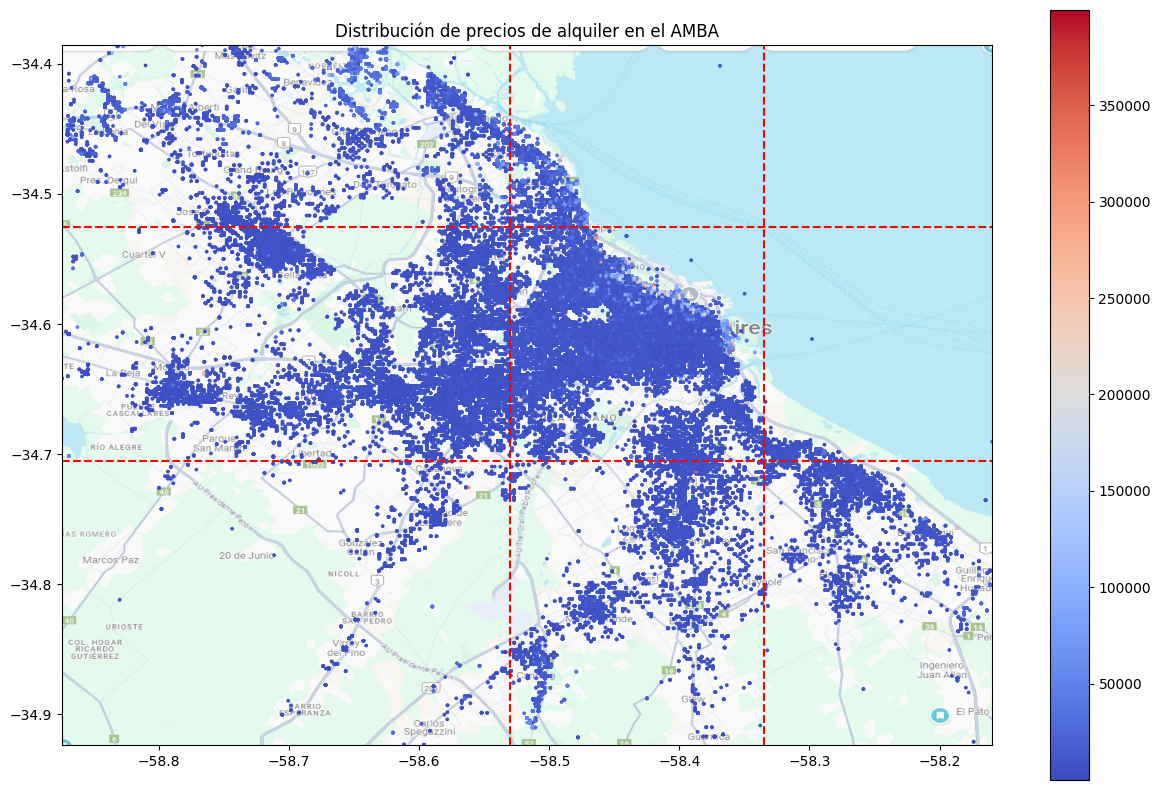

In [13]:
print(f'Cantidad de datos: {np.round(len(data) / 278725, 4)* 100} %')
gdf_amba = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.LONGITUDE, data.LATITUDE))

fig, ax = plt.subplots(figsize=(15, 10))
gdf_amba.plot(column='precio_pesos_constantes', cmap='coolwarm', legend=True, markersize=3, ax=ax)
img = plt.imread(r'img/map.jpg')
ax.imshow(img, extent=[data['LONGITUDE'].min(), data['LONGITUDE'].max(), data['LATITUDE'].min(), data['LATITUDE'].max()], alpha=0.6)
plt.axhline(y=-34.705, color='r', linestyle='--')
plt.axhline(y=-34.525, color='r', linestyle='--')
plt.axvline(x=-58.530, color='r', linestyle='--')
plt.axvline(x=-58.335, color='r', linestyle='--')
plt.title("Distribución de precios de alquiler en el AMBA")
plt.show()

Segun este grafico, decimos que la capital esta dada por el cuadrado central, mientras que la zona oeste por los cuadrados medio izquierdo e inferior izquierdo. Para la zona sur, decidimos los cuadrados inferiores central y derecho, y para la zona norte los cuadros superiores izquiero y central. Empezamos por la capital:

<h2 style="text-align: center;">Visualización geoespacial de precios: Capital Federal</h2>

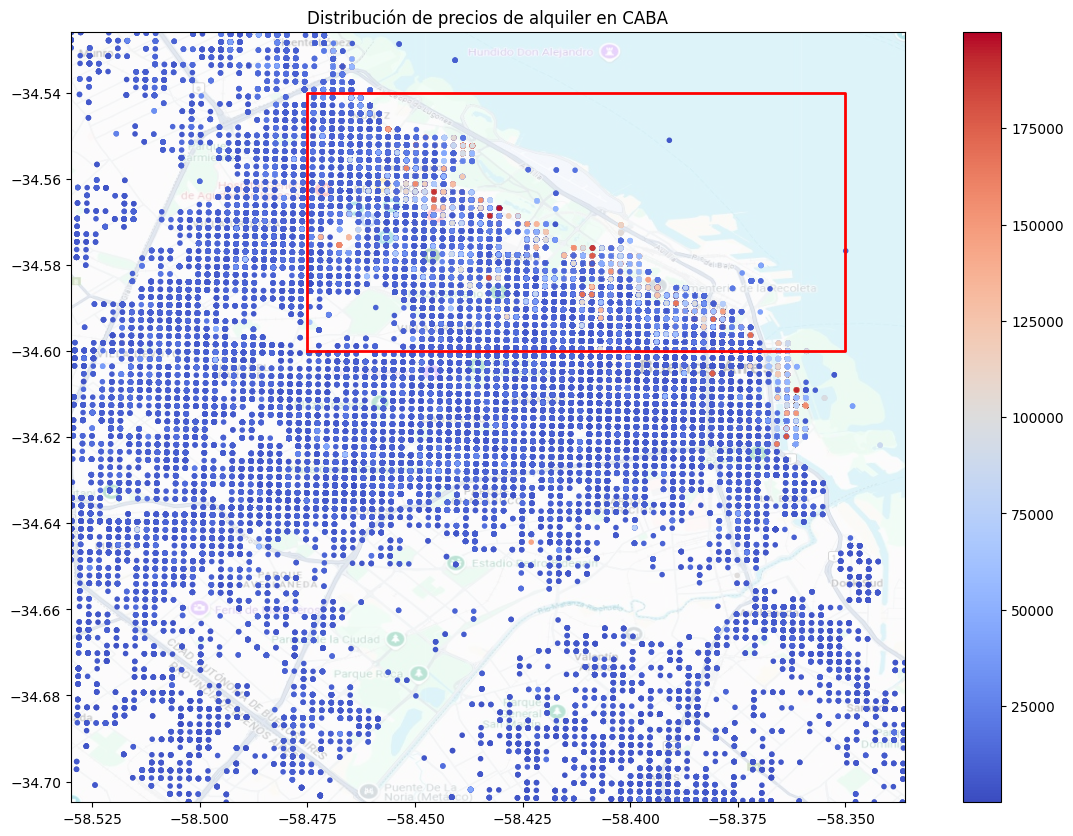

In [14]:
lat_min, lat_max = -34.705, -34.525
lon_min, lon_max = -58.530, -58.335

data_caba = data[(data['LATITUDE'] >= lat_min) & (data['LATITUDE'] <= lat_max) & (data['LONGITUDE'] >= lon_min) & (data['LONGITUDE'] <= lon_max)]
data_caba = data_caba[data_caba['precio_pesos_constantes'] < 200000]

gdf_caba = gpd.GeoDataFrame(data_caba, geometry=gpd.points_from_xy(data_caba.LONGITUDE, data_caba.LATITUDE))

fig, ax = plt.subplots(figsize=(15, 10))
gdf_caba.plot(column='precio_pesos_constantes', cmap='coolwarm', legend=True, markersize=9, figsize=(15, 10), ax=ax)
img = plt.imread(r'img/map_caba.jpg')
x_values = [-58.475, -58.475, -58.350, -58.350, -58.475]
y_values = [-34.60, -34.54, -34.54, -34.60, -34.60]
ax.plot(x_values, y_values, color='r', linewidth=2)
ax.imshow(img, extent=[data_caba['LONGITUDE'].min(), data_caba['LONGITUDE'].max(), data_caba['LATITUDE'].min(), data_caba['LATITUDE'].max()], alpha=0.3)
plt.title("Distribución de precios de alquiler en CABA")
plt.show()

En esta zona puede ser donde tal vez haya un poco de conflicto porque es donde se muestran los precios mas altos, por ende la prier figura muestra una distribucion que da poca informacion. Sin embargo, otros mapa de calor puede estar erroneos, ya que la escala toma todos los valores del dataset original (el proceesado) y puede que -en una zona- haya valores bastante mas bajos que el maximo de todos. Por tanto, para cada zona tomaremos aproximadamente a ojo el valor maximo para que sea representativo de la zona, tener en cuenta que no sirve hacerlo con codigo, porque tal vez hay un outlier que te arruina toda la distribucion (esta es una metodologia que se va a seguir en los casos sigueintes tambien). 

En este caso, si bien estamos con la escala correcta, vamos a sacarnos un par de valores de encima para ver un poco mejor la distribucion. Cuando sacamos esos valores altos, podemos empezar a ver la verdadera distribucion. Para esta region, podemos ver que los precios se distribuyen con cierta correlacion, a medida que nos vamos hacia el sur de la region, los precios tienden a bajar (al reves si vamos para el norte). Podemos ver patrones que los barrios mas cercanos al rio y a la zona centrica tienden a ser mas caros. Asi como barrios que estan al norte de la capital. Por otro lado, el oeste de la ciudad parece tener precios bajos, con algunas incosistencias. Los cuadrados rojos son los patrones que detectamos.

Para ver si esto es causado por alguna de las caracteristicas de nuestro modelo, chequeamos las posibles diferencias entre amenities entre la region completa y este patron que vemos:

-34.7048243916583 -34.5258204553111
-58.529971713346 -58.3361394491616


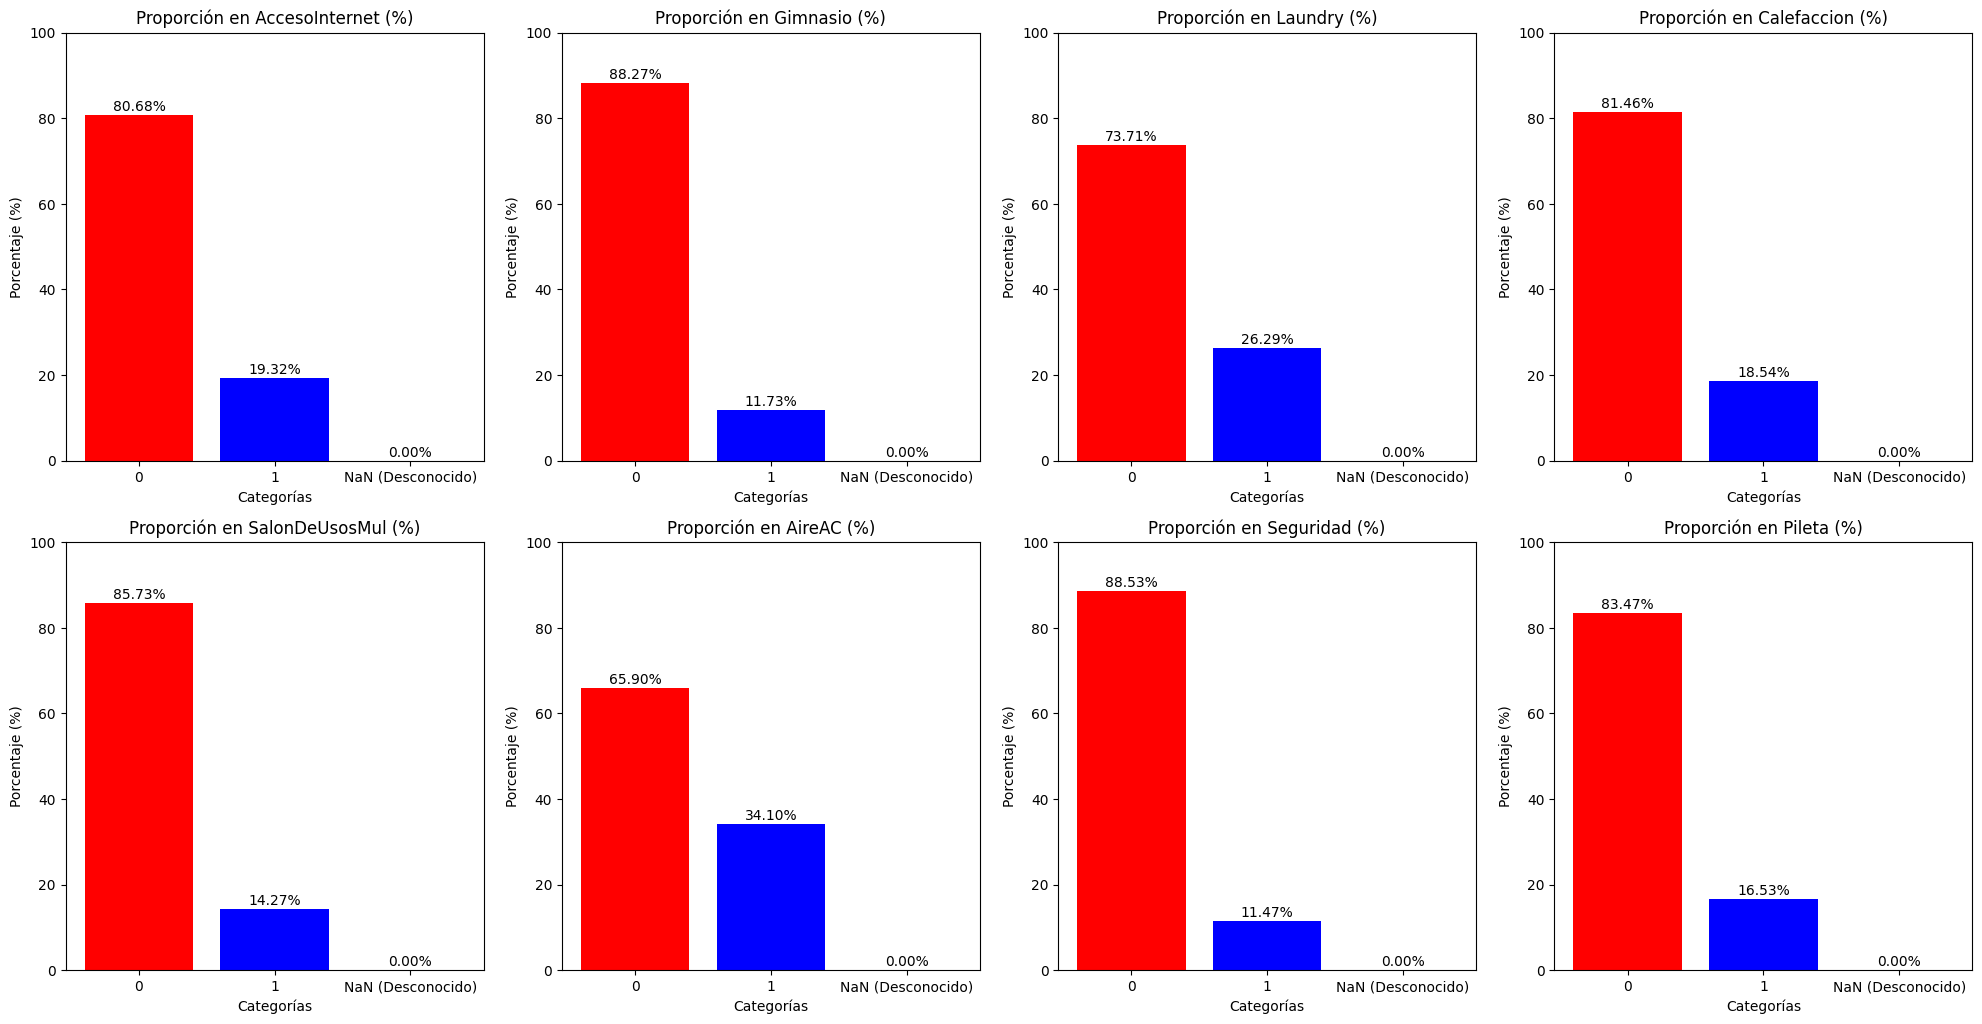

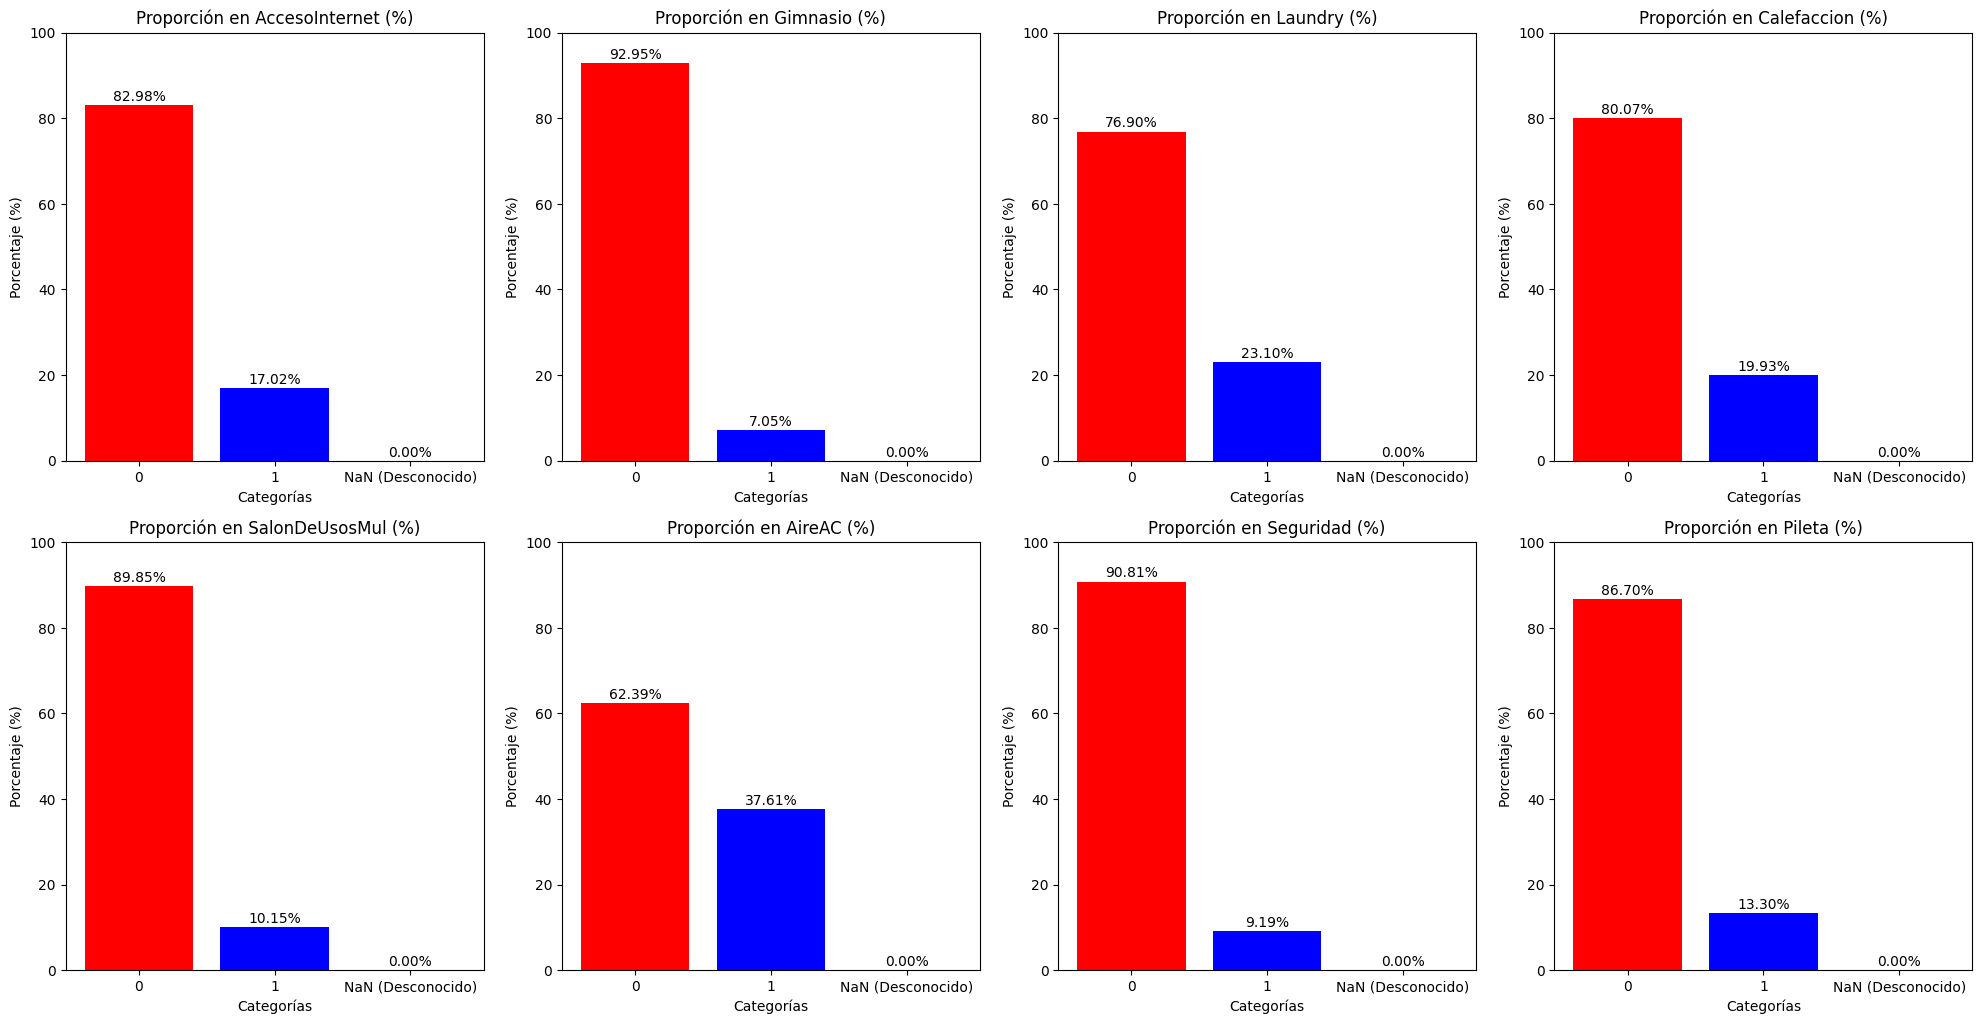

In [15]:
print(data_caba['LATITUDE'].min(), data_caba['LATITUDE'].max())
print(data_caba['LONGITUDE'].min(), data_caba['LONGITUDE'].max())

data_zona_patron = data[
    (data['LATITUDE'] >= -34.60) &
    (data['LATITUDE'] <= -34.54) &
    (data['LONGITUDE'] >= -58.475) &
    (data['LONGITUDE'] <= -58.350)
]
data_zona_patron = data_zona_patron[data_zona_patron['precio_pesos_constantes'] < 40000]

titles = [
    "AccesoInternet",
    "Gimnasio",
    "Laundry",
    "Calefaccion",
    "SalonDeUsosMul",
    "AireAC",
    "Seguridad",
    "Pileta"
]

ut.get_binary_plot(data_caba, titles)
ut.get_binary_plot(data_zona_patron, titles)

En este caso, vemos que no hay diferencias notables entre las amenities para la region en genral y para el area del patro observado. Por tanto, podemos decir que la diferencia de precios no se debe a las amenities. Para este caso esta bueno aclarar que los datos que se tomaron como parte del patron a diferenciar pudo haber sido errado en cierta medida, ya que nuestro patron se extiende en forma de un rectangulo rotado, por lo que es dificil tomar esos valores con coordenadas cuadradas sin ratcion.

Ademas, otra area importante a tener en cuenta para este patron es la seguridad. Si bien vemos que no hay cambio entre las zonas, historicamente la zona marcada por el patron (zona con mayores precios) tienen un menor inidice de inseguridad que el centro de la ciudad. Sin embargo, las zonas del oeste de la ciudad tambien tienen indices parecidos, por lo que no podemos afirmar que sea un factor determinante.

<img src="img/caba_crime.jpg">

Por ultimo, una cosa tambien que podemos considerar es el acceso al transporte. En esta area de la ciudad (area de precios mas elevados) se cuenta con una gran cantidad de subtes, colectivos y trenes que recorren toda la ciudad, facilitando el acceso al centro, entre otros lugares. Por otro lado, la zona oeste de la ciudad tiene menos acceso a estos medios de transporte, lo cual puede ser un factor determinante en la diferencia de precios.

<img src="img/caba_trans.jpg">

<h2 style="text-align: center;">Visualización geoespacial de precios: Bs. As. Oeste</h2>

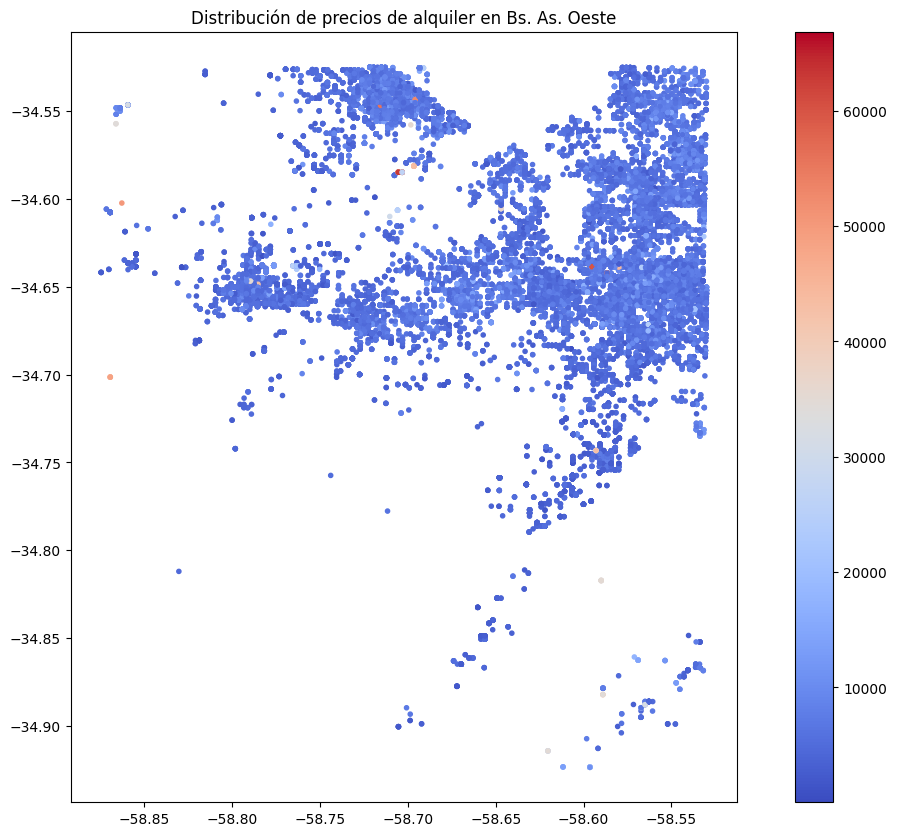

In [16]:
lat_min, lat_max = -34.705, -34.525
lon_min, lon_max = -58.530, -58.335

data_zonaO = data[(data['LATITUDE'] <= lat_max) & (data['LONGITUDE'] <= lon_min)]
data_zonaO = data_zonaO[data_zonaO['precio_pesos_constantes'] < 70000]

gdf_zonaO = gpd.GeoDataFrame(data_zonaO, geometry=gpd.points_from_xy(data_zonaO.LONGITUDE, data_zonaO.LATITUDE))

fig, ax = plt.subplots(figsize=(15, 10))
gdf_zonaO.plot(column='precio_pesos_constantes', cmap='coolwarm', legend=True, markersize=9, figsize=(15, 10), ax=ax)
#img = plt.imread(r'img/map_caba.jpg')
#ax.imshow(img, extent=[data_caba['LONGITUDE'].min(), data_caba['LONGITUDE'].max(), data_caba['LATITUDE'].min(), data_caba['LATITUDE'].max()], alpha=0.3)
plt.title("Distribución de precios de alquiler en Bs. As. Oeste")
plt.show()

Para este caso, decidimos establecer un valor maximo de 70.000. Aun asi, en este caso, vemos una distribucion de precios muy uniforme a lo largo de toda la region, si bien hay alguno puntos particulares con precios relativamente altos, no vemos un paton claro. Podemos ver que hay una zona en la parte superior central que algunos precios mas altos, pero no es algo que se pueda determinar un patron claro.

<h2 style="text-align: center;">Visualización geoespacial de precios: Bs. As. Sur</h2>

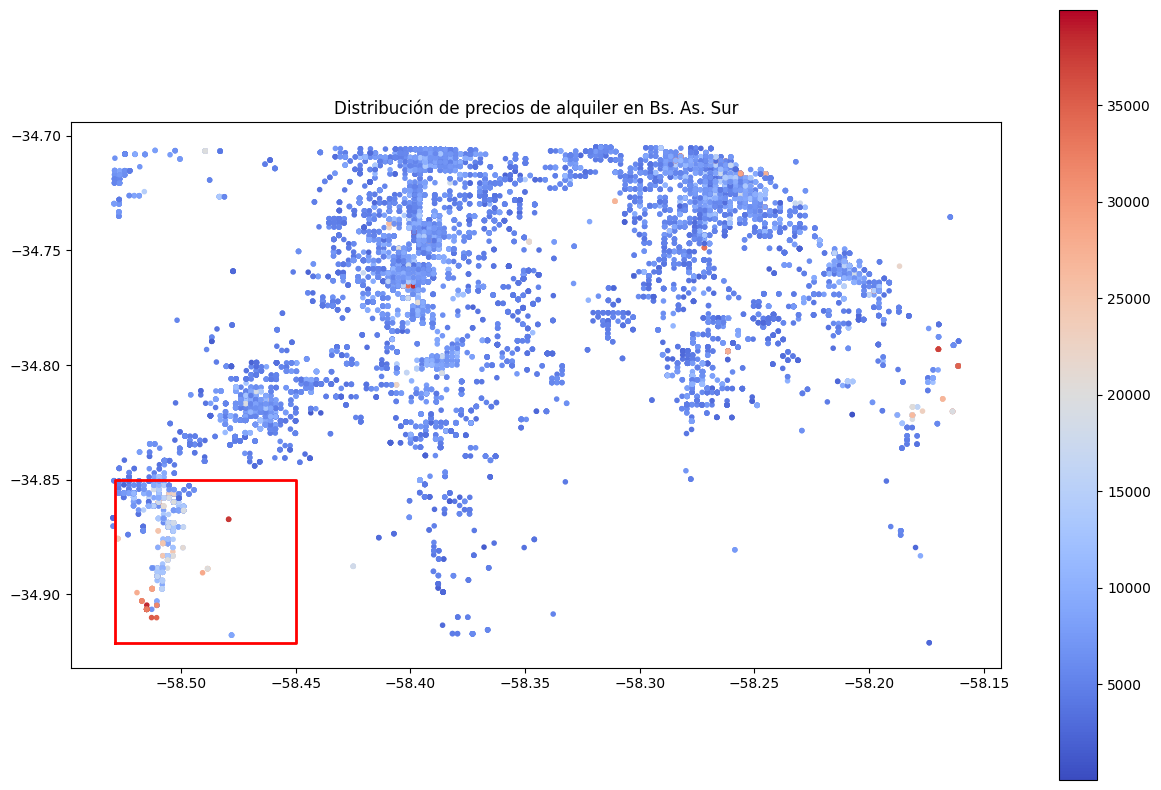

In [17]:
lat_min, lat_max = -34.705, -34.525
lon_min, lon_max = -58.530, -58.335

data_zonaS = data[(data['LATITUDE'] <= lat_min) & (data['LONGITUDE'] >= lon_min)]
data_zonaS = data_zonaS[data_zonaS['precio_pesos_constantes'] < 40000]

gdf_zonaS = gpd.GeoDataFrame(data_zonaS, geometry=gpd.points_from_xy(data_zonaS.LONGITUDE, data_zonaS.LATITUDE))

fig, ax = plt.subplots(figsize=(15, 10))
gdf_zonaS.plot(column='precio_pesos_constantes', cmap='coolwarm', legend=True, markersize=9, figsize=(15, 10), ax=ax)
#img = plt.imread(r'img/map_caba.jpg')
#ax.imshow(img, extent=[data_caba['LONGITUDE'].min(), data_caba['LONGITUDE'].max(), data_caba['LATITUDE'].min(), data_caba['LATITUDE'].max()], alpha=0.3)
x_values = [-58.529, -58.529, -58.45, -58.45, -58.529]
y_values = [-34.9211, -34.85, -34.85, -34.9211, -34.9211]
ax.plot(x_values, y_values, color='r', linewidth=2)
plt.title("Distribución de precios de alquiler en Bs. As. Sur")
plt.show()

Para el caso de la zona sur, ya podemos partir diciendo que es la region con los precios mas bajo de las cuatro hasta ahora. En cuanto a su distribucion espacial, podemos ver que esta region esta menos condensada que las otras dos, tiene dos grandes aglomeraciones en su parte norte (sur de la capital), y despues se desplaza hacia el sur en forma de camins largos. Para este caso, decidimos establecer un valor maximo de 40.000.

Respecto a la distribucion de precios, podemos ver que tanto en las partes condensadas como yendo para el sur hay gran uniformidad en los precios y relativamente bajos para lo que es la region. A simple vista, no parece haber un cambio notable a lo largo de la region. Sin embargo, podemos notar 1 (o tal vez 2) patrones que tienen valores ampliamente diferentes a los demas. Estos grupos estan en la esquina infreriro derecha y en el centro a la derecha, es decir en la parte mas al sur de la region (son los pueblos de Guernica y Berazategui).

Para ver las posibles causas de estos patrones, hacemos primero vemos si hay una diferencia en las amenities y caracteristicas no estructurales entre el promedio de la region y el promedio de estos barrios:

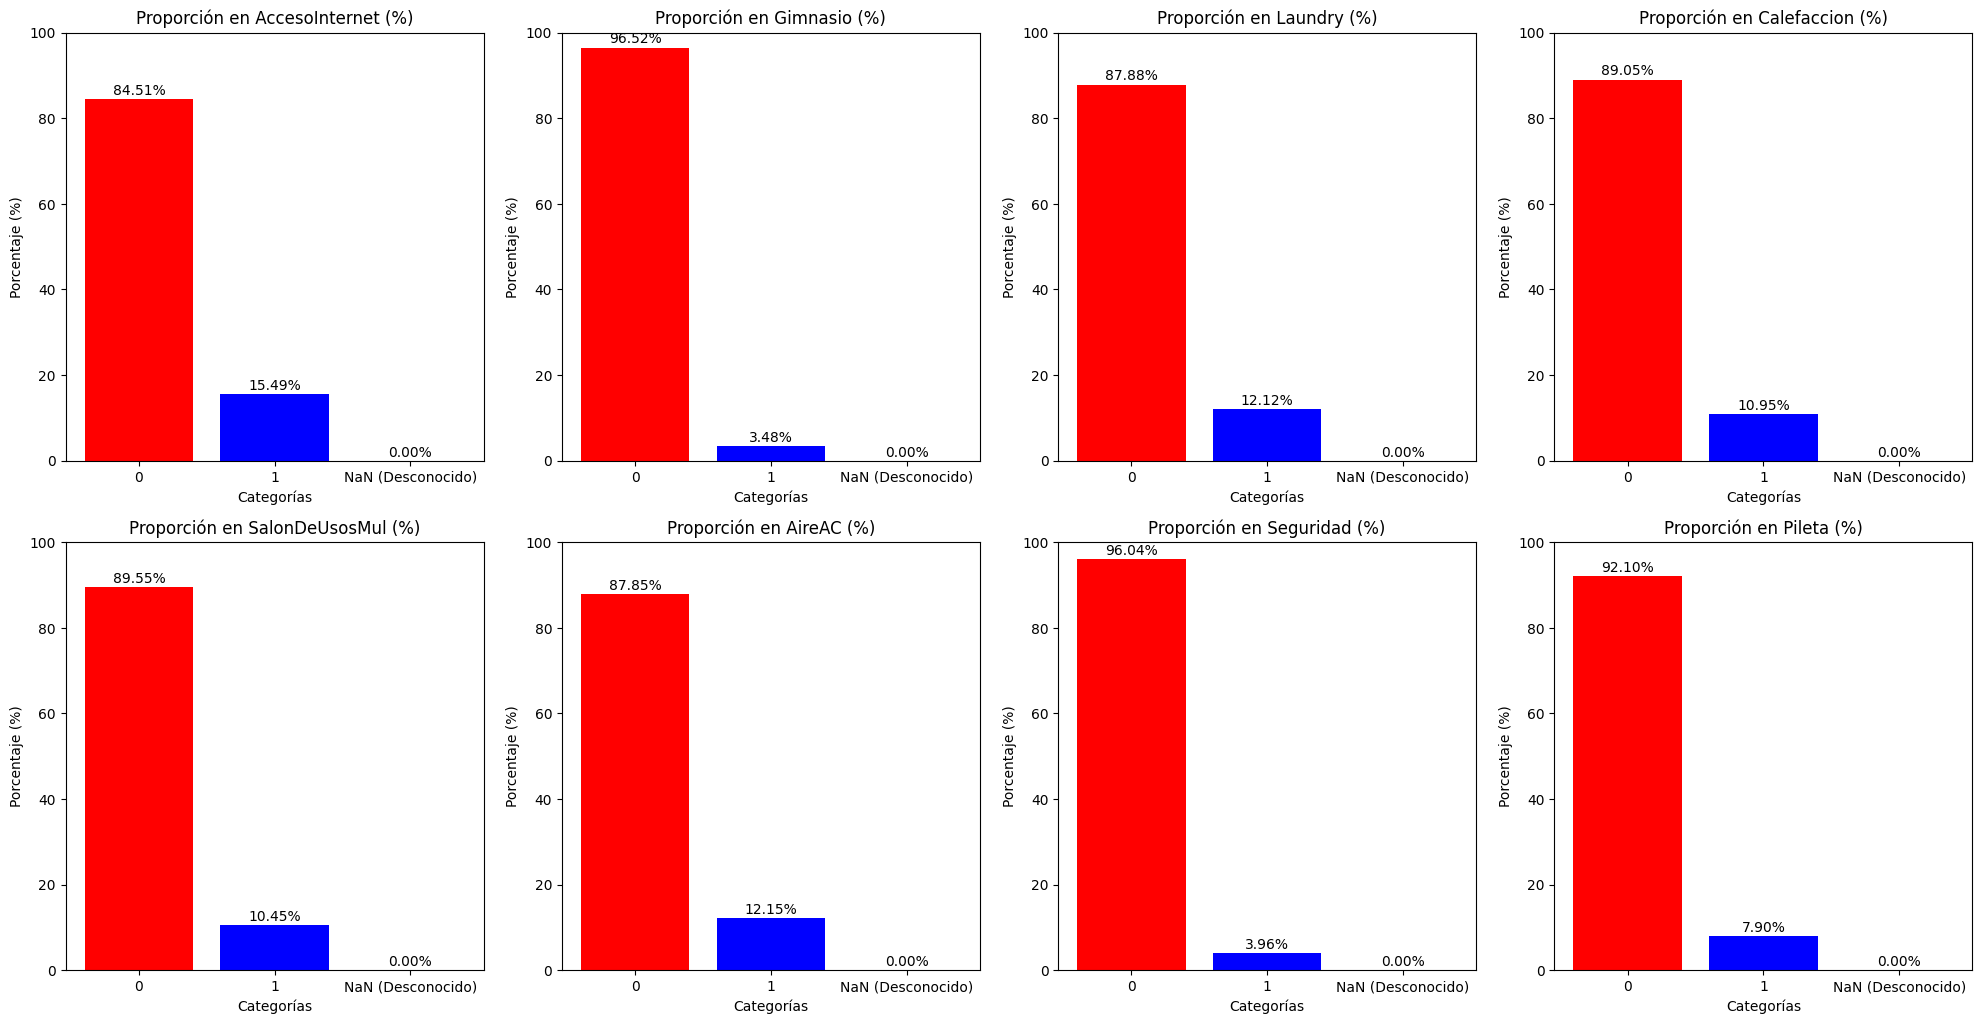

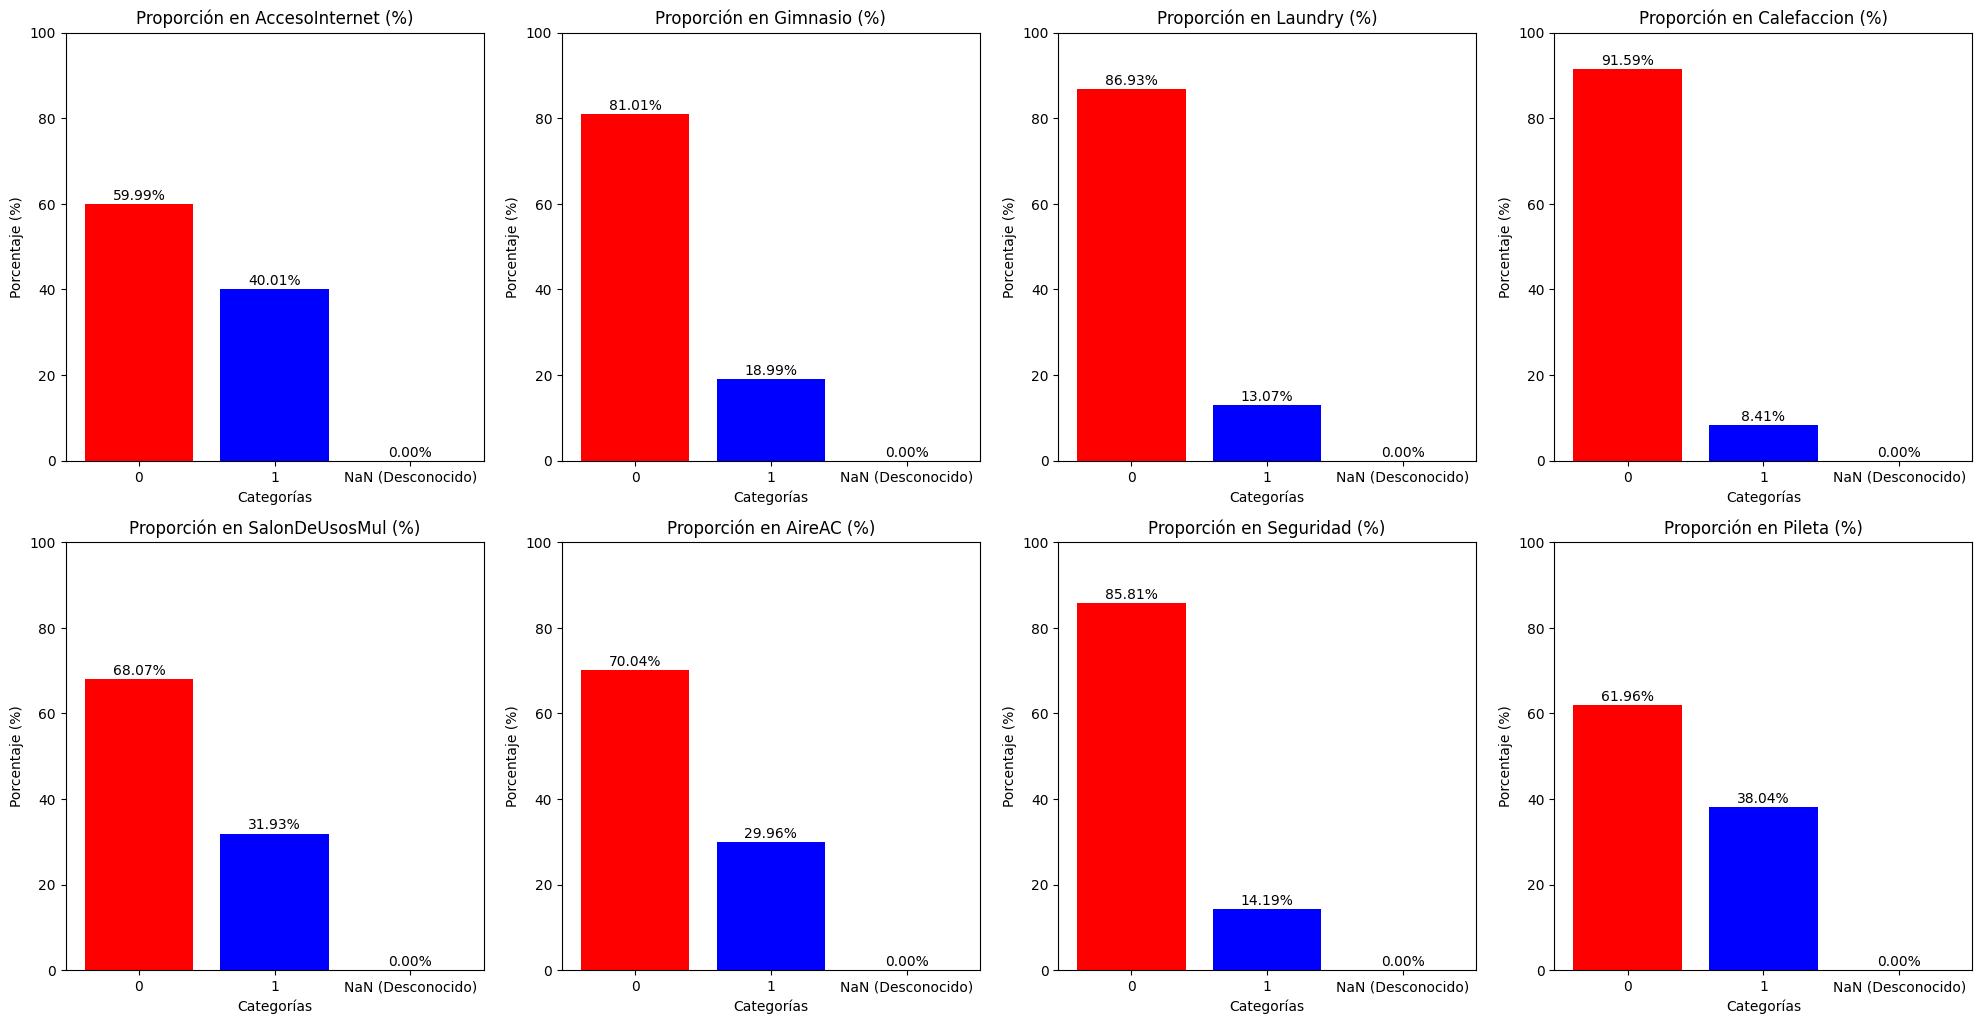

In [18]:
data_zonaS = data[(data['LATITUDE'] <= lat_min) & (data['LONGITUDE'] >= lon_min)]

data_zona_patron = data[
    (data['LATITUDE'] >= -34.9211) &
    (data['LATITUDE'] <= -34.85) &
    (data['LONGITUDE'] >= -58.529) &
    (data['LONGITUDE'] <= -58.45)
]
data_zona_patron = data_zona_patron[data_zona_patron['precio_pesos_constantes'] < 40000]

titles = [
    "AccesoInternet",
    "Gimnasio",
    "Laundry",
    "Calefaccion",
    "SalonDeUsosMul",
    "AireAC",
    "Seguridad",
    "Pileta"
]


ut.get_binary_plot(data_zonaS, titles)
ut.get_binary_plot(data_zona_patron, titles)

Como podemos ver, hay una suba general en los amenities para las propiedades dentro del patron observado, lo cual puede contribuir a la suba de precios con repecto al resto de la region.

Tambien, como se meustra en la figura debajo, podemos ver que tanto Guernica como Hudson (o la parte sur de esta region) tuvo un crecimiento significativo de barrios cerrados y countries. Estos  ofrecen servicios de vigilancia privada y mayor percepción de seguridad en comparación con otras zonas del sur del Gran Buenos Aires. Ademas, Estas localidades suelen atraer a personas que buscan evitar las problemáticas de las áreas urbanas más densamente pobladas, como el ruido y el hacinamiento. 

Asimismo, otra cosa que tienen a favor estas localiadades son el facil acceso a rutas importantes y transporte publico (tren) cerca. Si bien puede no verse en la imagen, Hudson, en particular, está cerca de la Autopista Buenos Aires-La Plata, lo que facilita el acceso rápido a la Capital Federal y a otros puntos importantes del conurbano. Guernica, más alejada, tiene acceso razonable al tren y rutas principales.

<img src="img/map_sur.jpg">

<h2 style="text-align: center;">Visualización geoespacial de precios: Bs. As. Norte</h2>

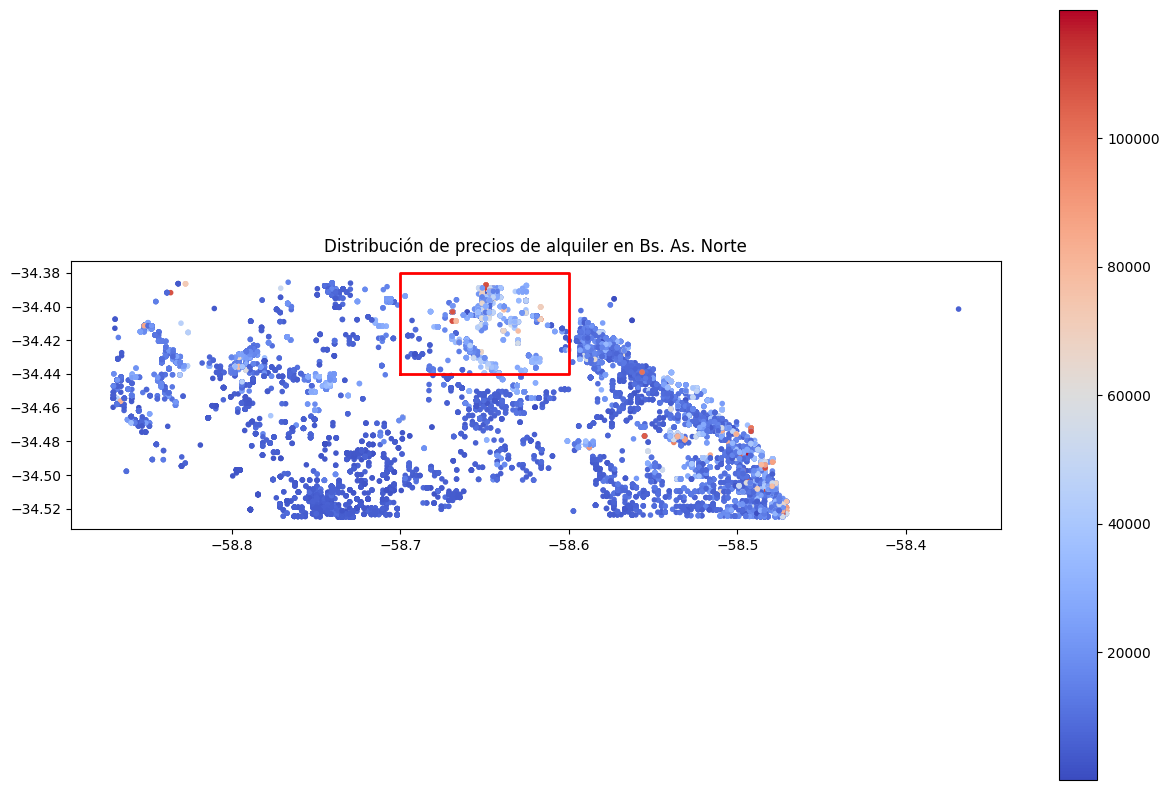

In [19]:
lat_min, lat_max = -34.705, -34.525
lon_min, lon_max = -58.530, -58.335

data_zonaN = data[
    (data['LATITUDE'] >= lat_max) &
    (data['LONGITUDE'] <= lon_max)
]
data_zonaN = data_zonaN[data_zonaN['precio_pesos_constantes'] < 120000]

gdf_zonaN = gpd.GeoDataFrame(data_zonaN, geometry=gpd.points_from_xy(data_zonaN.LONGITUDE, data_zonaN.LATITUDE))

fig, ax = plt.subplots(figsize=(15, 10))
gdf_zonaN.plot(column='precio_pesos_constantes', cmap='coolwarm', legend=True, markersize=9, figsize=(15, 10), ax=ax)
#img = plt.imread(r'img/map_caba.jpg')
#ax.imshow(img, extent=[data_caba['LONGITUDE'].min(), data_caba['LONGITUDE'].max(), data_caba['LATITUDE'].min(), data_caba['LATITUDE'].max()], alpha=0.3)

x_values = [-58.7, -58.7, -58.6, -58.6, -58.7]
y_values = [-34.44, -34.38, -34.38, -34.44, -34.44]
ax.plot(x_values, y_values, color='r', linewidth=2)
plt.title("Distribución de precios de alquiler en Bs. As. Norte")
plt.show()

Finalmente, para la zona norte, vemos que es la region con el precio mas elevado (120000), sin contar la capital federal. En cuanto a distribucion espacial, podemos notar cierta aglomeracion en la zona de San Fernando, Beccar, y alrededores. Sin embargo, mas hacia el noroeste, tenemos nordelta y, nuevamente, una gran aglomeracion de barrios cerrados. Razon bastante importante para describir tanto los precios como la distribucion espacial.

<img src="img/map_norte.jpg">

En cuanto a la dsitribucion de precios, podemos identificar 3 zonas principales: la zona izquierda del norte, que incluye don torcuarto, los plovorines, lugar mas residencial, que luego se extiende hasta pilar/villa rosa, donde nuevamente empiezan a aparecer barrios cerrados. Por otra parte, tenemos el norte de la ciudad, en donde hay una gran variedad de precios, pero en general no son altos. Parece haber una tendencia de mayor precio a medida que se acercan al rio, pero no es algo que se pueda afirmar con certeza. Por ultimo, tenemos la zona de nordelta y sus alrededores (barrios cerrados), que es la mas cara de la region, y donde se concentran los barrios cerrados.

Para ver las posibles causas de estos patrones, hacemos primero vemos si hay una diferencia en las amenities y caracteristicas no estructurales entre el promedio de la region y el promedio de estos barrios:

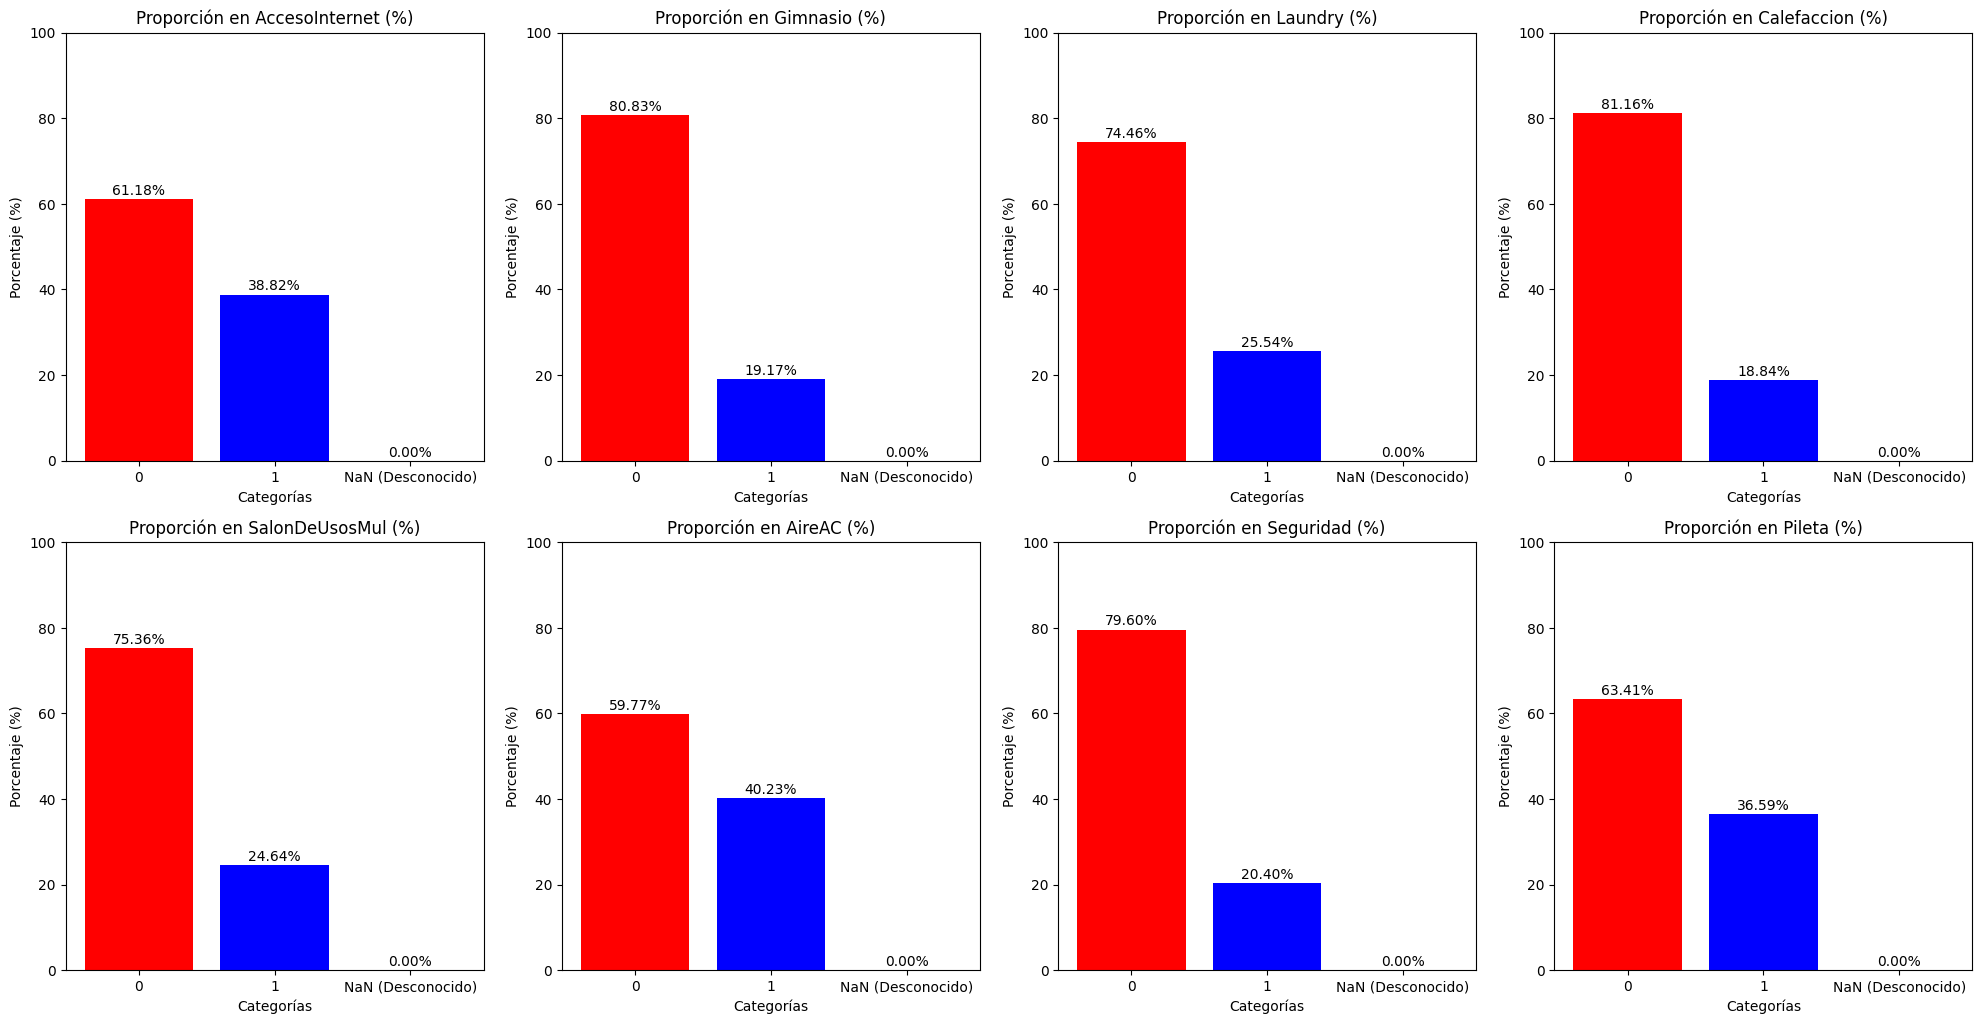

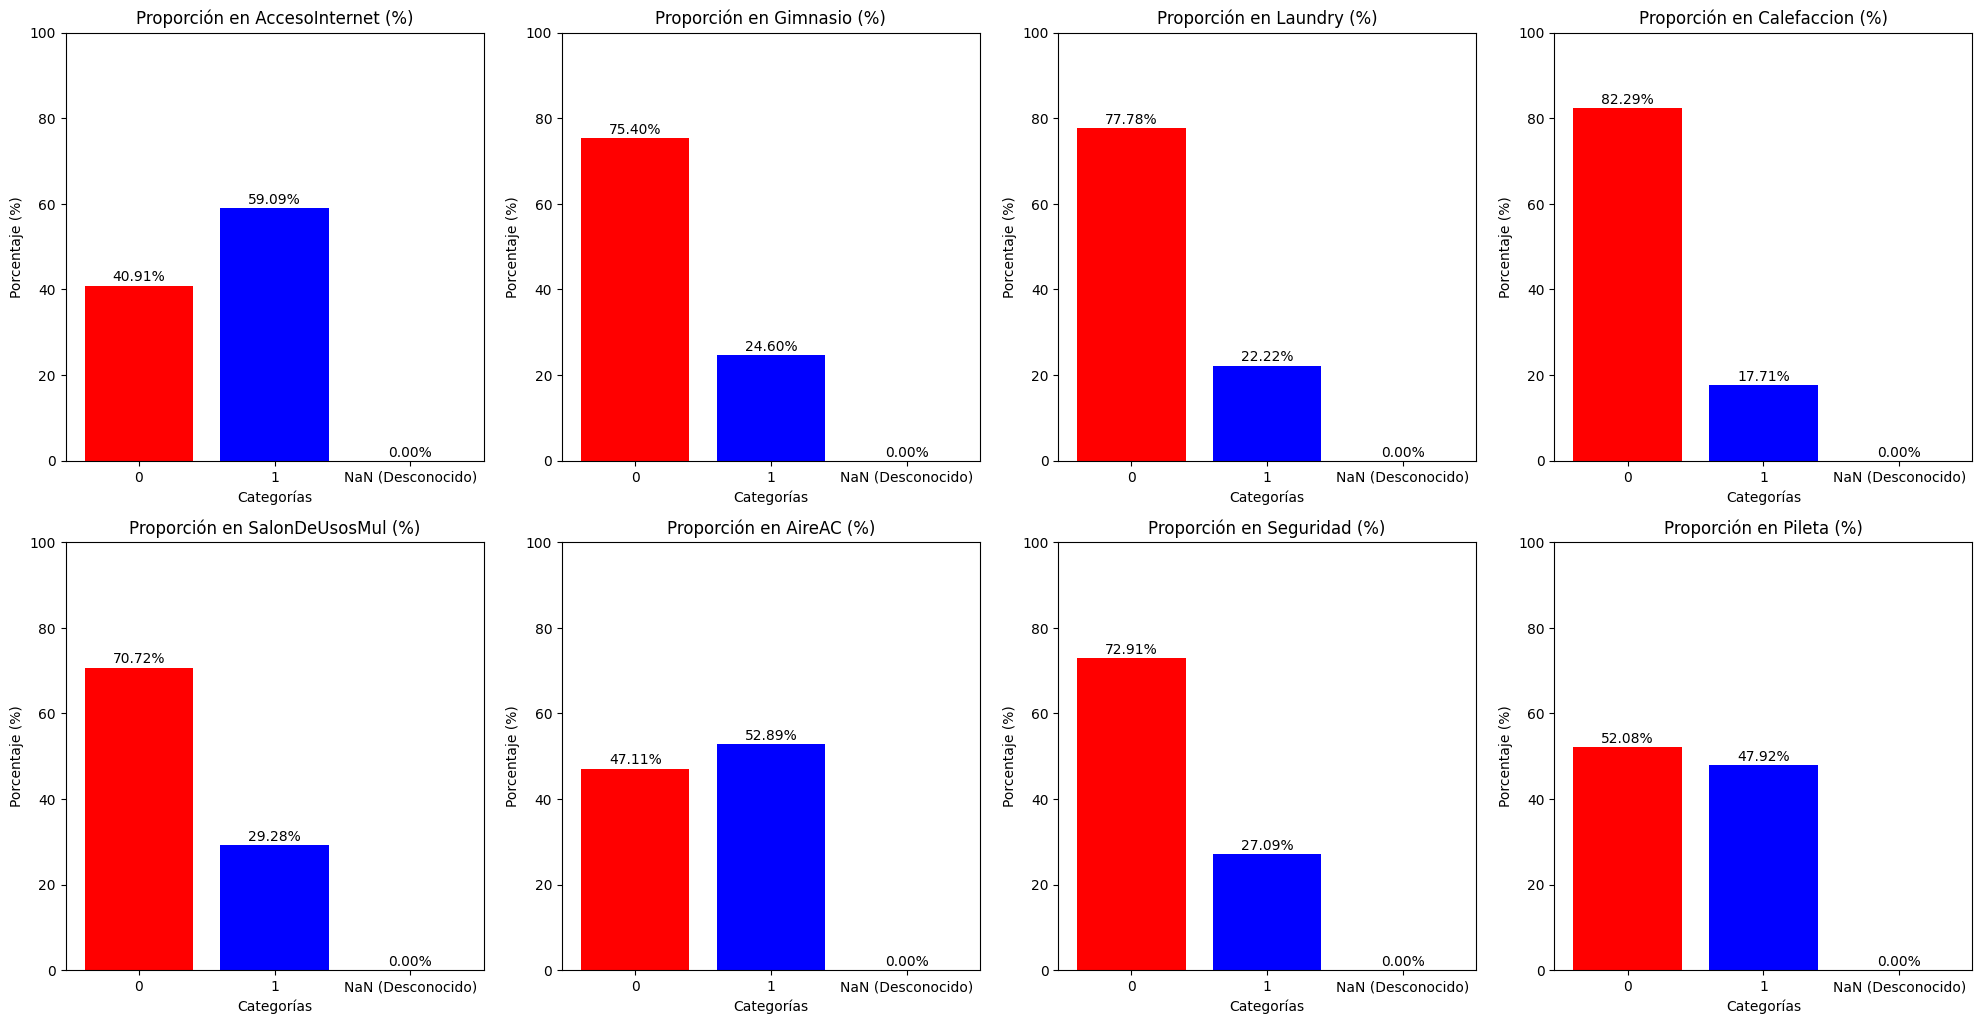

In [20]:
data_zonaN = data[
    (data['LATITUDE'] >= lat_max) &
    (data['LONGITUDE'] <= lon_max)
]

data_zona_patron = data[
    (data['LATITUDE'] >= -34.44) &
    (data['LATITUDE'] <= -34.38) &
    (data['LONGITUDE'] >= -58.7) &
    (data['LONGITUDE'] <= -58.6)
]
data_zona_patron = data_zona_patron[data_zona_patron['precio_pesos_constantes'] < 120000]

titles = [
    "AccesoInternet",
    "Gimnasio",
    "Laundry",
    "Calefaccion",
    "SalonDeUsosMul",
    "AireAC",
    "Seguridad",
    "Pileta"
]

ut.get_binary_plot(data_zonaN, titles)
ut.get_binary_plot(data_zona_patron, titles)

Por lo que podemos ver de los graficos, la zona del patron que nos interesa muestra una suba notable en la gran mayoria de los amenities, pr lo que sigue respaldando nuestra hipotesis de que pueden ser un factor importante en la diferencia de precios.

Asimismo, como habiamos dicho antes, los barrios cerrrados proporcionan una mayor seguridad y de accesso al mismo. Sin embargo, lo difernte de nordelta con los barrios de por ejemplo, zona sur, es que nordelta es un concepto de ciudad pueblo, donde no solo se brinda seguridad y aislamiento, sino que tambien incluye un desarollo urbano propio, donde tienen shoppings, restaurantes, colegios, hospitales, entre otros. Ademas, la zona de nordelta esta cerca de la autopista panamericana, lo cual facilita el acceso a la capital federal y a otros puntos importantes del conurbano. Todo esto hace que la zona se revalorize mucho en comparacion al resto de las zonas mas residenciales.

<h2 style="text-align: center;">Conclusiones</h2>

Una vez terminado nuestro analisi, podemos concluir:

Para los lugares donde se encontro patron de precios altos, y se tomo los datos del patron de forma correcta, se encontro una correlacion positiva entre los precios y las amenities. Por tanto, hay indicios de que los precios de alquiler en el AMBA estan relacionados con la cantidad de 'ammenities' que posee la propiedad. Sin embargo, habria que hacer un estudio mayor (sobre mas categorias) para determinar la relacion exacta. Tambien es bueno destacar, que otras posibles razones por las que los precios pueden variar son la seguridad y el acceso al transporte, como se vio en los casos de la capital federal, la zona sur y norte (seguridad en las zonas sur y norte nos referimos a la existencia de barrios privados).